В чём основная проблема переобучения?

→ Модель показывает исключительно хорошие результаты на обучающих данных, но плохие — на новых данных, что указывает на слабую обобщающую способность.

Почему мы не можем оценить модель на обучающих данных?

→ Потому что модель «запомнила» шум и детали в обучающих данных, не отражая свою производительность в реальных условиях, что приводит к чрезмерно оптимистичным оценкам.

Что такое регуляризация? Как она помогает контролировать сложность модели?

→ Регуляризация добавляет штрафной член за сложность модели (например, нормы L1 или L2) к функции потерь, ограничивая размер параметров и тем самым предотвращая переобучение модели на шуме в обучающих данных, улучшая обобщающую способность.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
np.random.seed(42)

Task 1: Iris Dataset Analysis and Binary Classification
Load the Iris dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 转换为 DataFrame 便于后续操作
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].map({i: name for i, name in enumerate(target_names)})

print("datashape:", df.shape)
df.head()

数据形状: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Plot a pairplot for visualization analysis

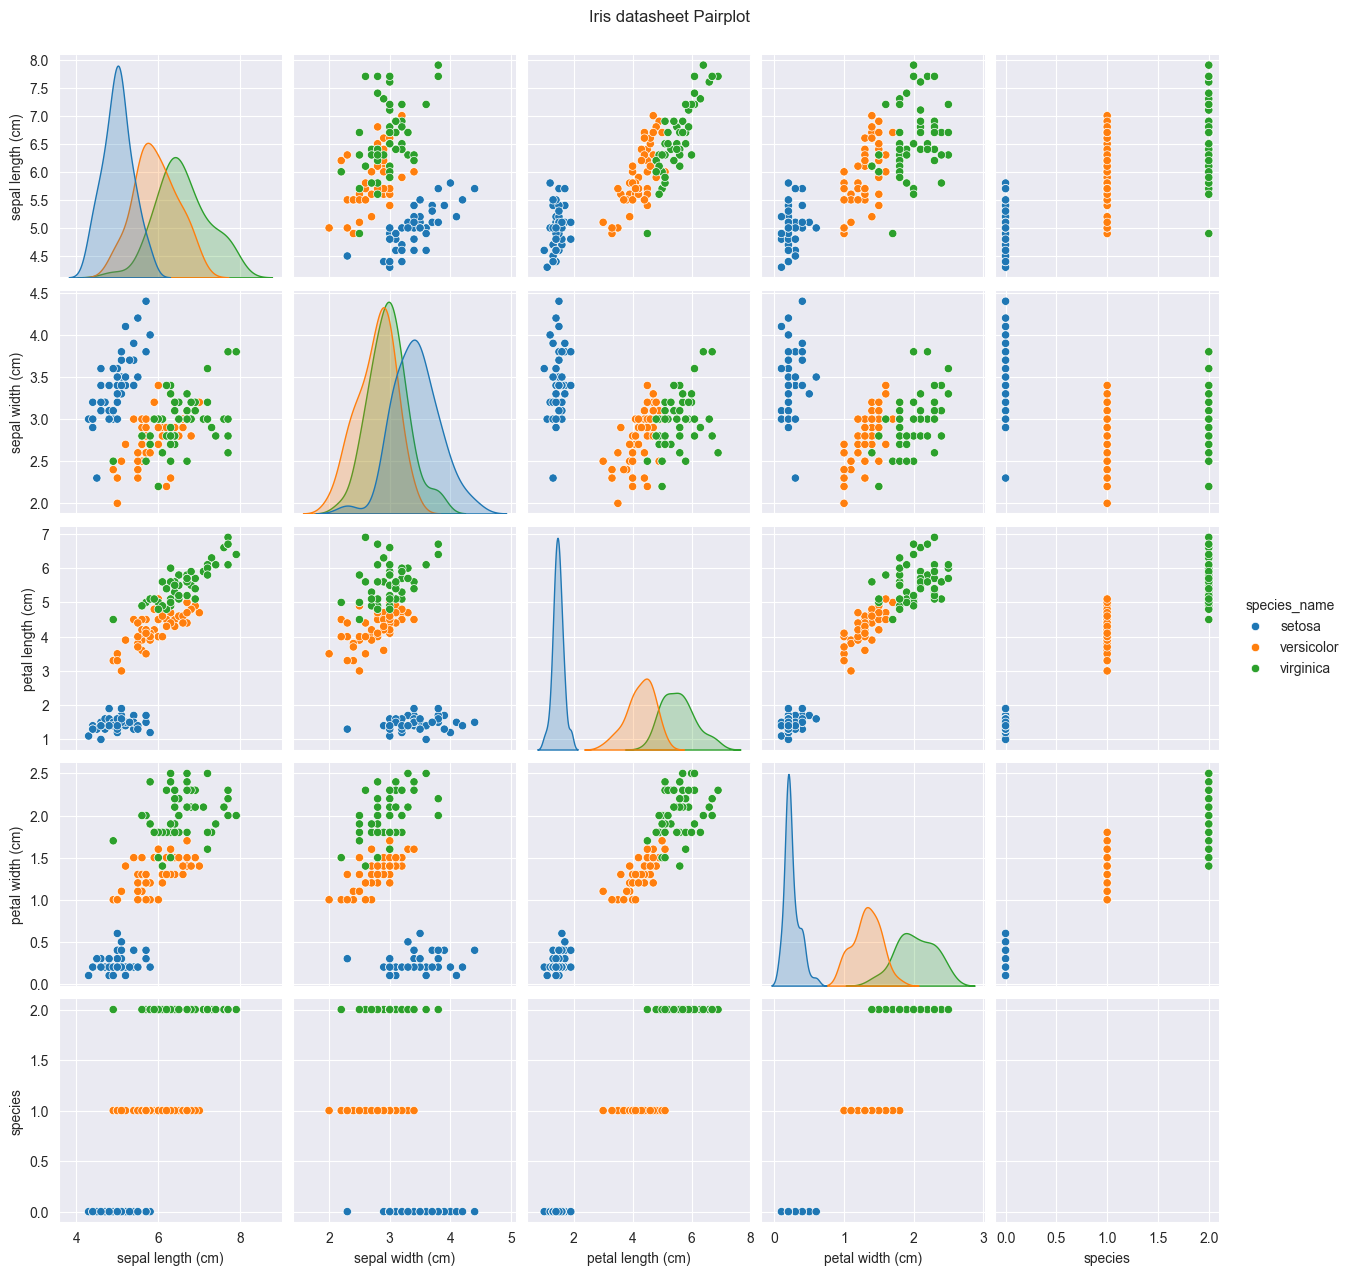

In [4]:
sns.pairplot(df, hue='species_name', diag_kind='kde')
plt.suptitle("Iris datasheet Pairplot", y=1.02)
plt.show()

Observation and Analysis: As can be seen from the figure, setosa (category 0) is clearly separated from the other two categories in terms of petal length and width, while versicolor (category 1) and virginica (category 2) have some overlap. Therefore, petal features can effectively distinguish setosa, but distinguishing the latter two categories requires a more complex model.

To perform binary classification, we select only the first two categories (setosa and versicolor), transforming the problem into distinguishing between mountain iris and color-changing iris.

In [5]:
# 只选择类别 0 和 1
df_bin = df[df['species'] < 2].copy()
X_bin = df_bin[feature_names]
y_bin = df_bin['species']

# 划分训练集和测试集（70% 训练，30% 测试）
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

print("size training:", X_train.shape[0])
print("size teating:", X_test.shape[0])

size training: 70
size teating: 30


Training a logistic regression model

Train set accuracy: 1.0000
Test set accuracy: 1.0000
Confusion Matrix:
[[15  0]
 [ 0 15]]


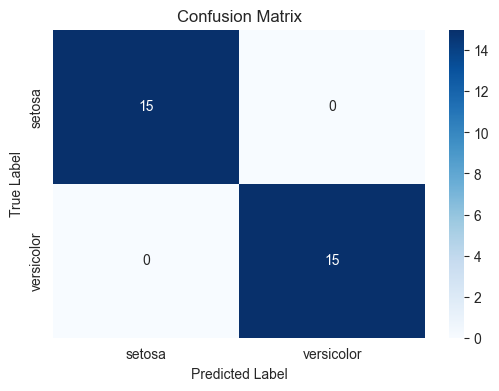

In [12]:
# 创建并训练模型
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)

# 预测
y_pred = logreg.predict(X_test)
y_train_pred = logreg.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Train set accuracy: {train_acc:.4f}")

# 评估
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test set accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor'],
            yticklabels=['setosa', 'versicolor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Task 2: Demonstration of overfitting in linear regression

Generating Nonlinear Data: We generate a noisy sine function to simulate nonlinear relationships in the real world.

In [7]:
# 生成训练数据
X_train_ol = np.sort(np.random.rand(30, 1) * 10, axis=0)
y_train_ol = np.sin(X_train_ol).ravel() + np.random.normal(0, 0.2, X_train_ol.shape[0])

# 生成测试数据（无噪声的理想正弦值，用于评估泛化能力）
X_test_ol = np.linspace(0, 10, 100).reshape(-1, 1)
y_test_ol = np.sin(X_test_ol).ravel()

Using polynomial regression with different complexities

We fitted the data using first-order (linear) and 15th-order polynomials respectively, and observed their performance on the training and test sets.

In [13]:
# 低阶模型：degree = 1
model_low = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_low.fit(X_train_ol, y_train_ol)
y_train_pred_low = model_low.predict(X_train_ol)
y_test_pred_low = model_low.predict(X_test_ol)

# 高阶模型：degree = 15
model_high = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_high.fit(X_train_ol, y_train_ol)
y_train_pred_high = model_high.predict(X_train_ol)
y_test_pred_high = model_high.predict(X_test_ol)

# 计算均方误差
mse_train_low = mean_squared_error(y_train_ol, y_train_pred_low)
mse_test_low = mean_squared_error(y_test_ol, y_test_pred_low)
mse_train_high = mean_squared_error(y_train_ol, y_train_pred_high)
mse_test_high = mean_squared_error(y_test_ol, y_test_pred_high)

print("low-order polynomials（degree=1） - trainMSE: {:.4f}, teatMSE: {:.4f}".format(mse_train_low, mse_test_low))
print("high-order polynomials（degree=15）- trainMSE: {:.4f}, testMSE: {:.4f}".format(mse_train_high, mse_test_high))

low-order polynomials（degree=1） - trainMSE: 0.6196, teatMSE: 0.4530
high-order polynomials（degree=15）- trainMSE: 0.0196, testMSE: 0.0635


Visualize the fitted curve

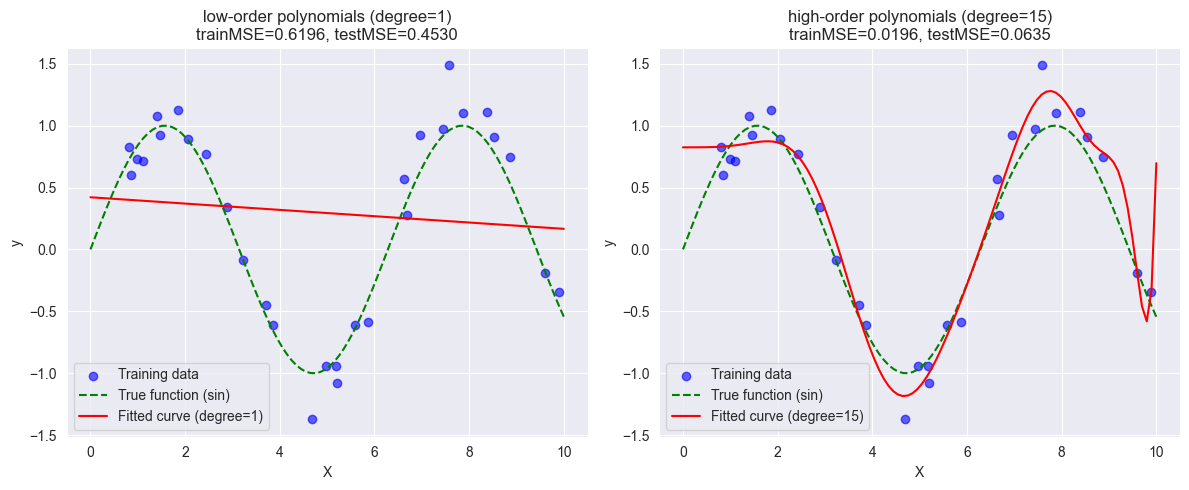

In [10]:
plt.figure(figsize=(12, 5))

# 左图：低阶模型
plt.subplot(1, 2, 1)
plt.scatter(X_train_ol, y_train_ol, color='blue', label='Training data', alpha=0.6)
plt.plot(X_test_ol, y_test_ol, color='green', linestyle='--', label='True function (sin)')
plt.plot(X_test_ol, y_test_pred_low, color='red', label='Fitted curve (degree=1)')
plt.title(f'low-order polynomials (degree=1)\ntrainMSE={mse_train_low:.4f}, testMSE={mse_test_low:.4f}')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# 右图：高阶模型
plt.subplot(1, 2, 2)
plt.scatter(X_train_ol, y_train_ol, color='blue', label='Training data', alpha=0.6)
plt.plot(X_test_ol, y_test_ol, color='green', linestyle='--', label='True function (sin)')
plt.plot(X_test_ol, y_test_pred_high, color='red', label='Fitted curve (degree=15)')
plt.title(f'high-order polynomials (degree=15)\ntrainMSE={mse_train_high:.4f}, testMSE={mse_test_high:.4f}')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

Results Analysis

Low-order model (degree=1): The fitted curve is a straight line, failing to capture the fluctuations of the sine function, resulting in large training and testing errors, indicating underfitting.

High-order model (degree=15): The fitted curve is very tortuous, almost traversing all training data points. Training error is minimal, but the error on the test set is large because the model overfits the noise in the training data and cannot generalize to new data points; this is typical overfitting.

Conclusion: Model complexity has a significant impact on generalization ability. Choosing an appropriate model complexity (or using regularization) is key to preventing overfitting.
